# 1. Business Understanding
##LATAR BELAKANG:
Dataset berisi ribuan resep ayam dengan informasi jumlah kalori per resep. Dengan mempelajari pola dari judul, bahan,
langkah memasak, popularitas (Loves), dan metadata lainnya,  dapat memprediksi kalori suatu resep. Ini berguna untuk
sistem rekomendasi makanan sehat atau perencanaan diet.

##BUSINESS QUESTION:
"Dapatkah model machine learning memprediksi jumlah kalori resep ayam dengan performa MAE ≤ 75 kkal dan R² ≥ 0.75?"

##HIPOTESIS:
Semakin kompleks bahan dan langkah, semakin tinggi kalori. Popularitas (Loves) juga mungkin berkorelasi.

##MANFAAT:
Membantu pengguna memilih resep sesuai target kalori.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import pickle
import warnings
warnings.filterwarnings('ignore')

# 2. Data Understanding

In [4]:
df = pd.read_csv('cleaned_nutrition_data.csv')
print("Dataset shape:", df.shape)
print("Kolom:\n", df.columns.tolist())
print("\nContoh data:\n", df.head(2))
print("\nInfo dataset:")
df.info()
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplikat:", df.duplicated().sum())

Dataset shape: (15641, 8)
Kolom:
 ['Title', 'Ingredients', 'Steps', 'Loves', 'URL', 'jenis_makanan', 'usia', 'jumlah_kalori']

Contoh data:
                       Title  \
0          Ayam Woku Manado   
1  Ayam goreng tulang lunak   

                                         Ingredients  \
0  1 Ekor Ayam Kampung (potong 12)--2 Buah Jeruk ...   
1  1 kg ayam (dipotong sesuai selera jangan kecil...   

                                               Steps  Loves  \
0  Cuci bersih ayam dan tiriskan. Lalu peras jeru...      1   
1  Haluskan bumbu2nya (BaPut, ketumbar, kemiri, k...      1   

                                          URL jenis_makanan  usia  \
0          /id/resep/4473027-ayam-woku-manado          ayam    52   
1  /id/resep/4471956-ayam-goreng-tulang-lunak          ayam    15   

   jumlah_kalori  
0         883.91  
1        1120.38  

Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15641 entries, 0 to 15640
Data columns (total 8 columns):
 #   Column       

In [5]:
# Statistik deskriptif target
print("\nStatistik jumlah_kalori:\n", df['jumlah_kalori'].describe())


Statistik jumlah_kalori:
 count    15641.000000
mean       779.826252
std        417.901939
min         50.070000
25%        419.400000
50%        783.510000
75%       1138.750000
max       1499.890000
Name: jumlah_kalori, dtype: float64


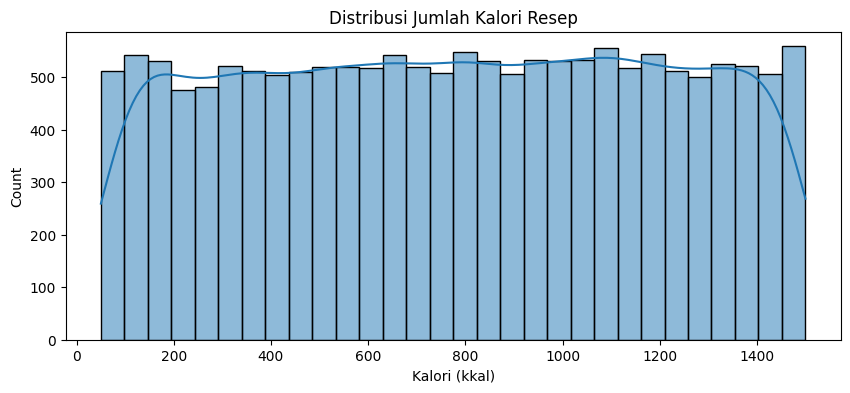

In [6]:
# Visualisasi distribusi target
plt.figure(figsize=(10,4))
sns.histplot(df['jumlah_kalori'], bins=30, kde=True)
plt.title('Distribusi Jumlah Kalori Resep')
plt.xlabel('Kalori (kkal)')
plt.show()

# 3. Feature Engineering

In [8]:
#Mengekstrak fitur dari teks
#Fitur dari kolom title
df['title_length'] = df['Title'].fillna('').apply(len)
df['title_word_count'] = df['Title'].fillna('').apply(lambda x: len(x.split()))

# Fitur dari kolom Ingredients (jumlah bahan, panjang teks)
def count_ingredients(ing_str):
    if pd.isna(ing_str):
        return 0
    # bahan dipisah dengan '--' di dataset
    return len(ing_str.split('--'))

df['num_ingredients'] = df['Ingredients'].fillna('').apply(count_ingredients)
df['ingredients_length'] = df['Ingredients'].fillna('').apply(len)

# Fitur dari kolom Steps (jumlah langkah, panjang teks)
df['num_steps'] = df['Steps'].fillna('').apply(lambda x: len(x.split('--')))
df['steps_length'] = df['Steps'].fillna('').apply(len)

# Fitur dari kolom URL (panjang, apakah ada kata tertentu)
df['url_length'] = df['URL'].fillna('').apply(len)

# Fitur interaksi: Loves × usia (popularitas relatif terhadap usia)
df['loves_usia_interaction'] = df['Loves'] * df['usia']

# Encoding jenis_makanan (meskipun hanya 'ayam', tetap encoding)
le = LabelEncoder()
df['jenis_makanan_encoded'] = le.fit_transform(df['jenis_makanan'].fillna('unknown'))

# Pilih fitur numerik untuk modeling
feature_columns = [
    'usia', 'Loves', 'title_length', 'title_word_count',
    'num_ingredients', 'ingredients_length', 'num_steps', 'steps_length',
    'url_length', 'loves_usia_interaction', 'jenis_makanan_encoded'
]
X = df[feature_columns].copy()
y = df['jumlah_kalori'].copy()

# Hapus baris dengan missing value pada X atau y
valid_idx = X.notna().all(axis=1) & y.notna()
X = X[valid_idx]
y = y[valid_idx]
print(f"Setelah hapus missing: {X.shape[0]} sampel")

Setelah hapus missing: 15641 sampel


# 4. Scaling & Train-Test Split

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 12512, Test size: 3129


# 5. Modeling (3 algoritma)

In [12]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100),
    'XGBoost': xgb.XGBRegressor(random_state=42, n_estimators=100, verbosity=0)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2, 'MAPE': mape}
    print(f"\n{name:20} \nMAE={mae:.2f} \nRMSE={rmse:.2f} \nR²={r2:.4f} \nMAPE={mape:.2f}%")


Linear Regression    
MAE=362.29 
RMSE=418.19 
R²=-0.0018 
MAPE=108.96%

Random Forest        
MAE=366.46 
RMSE=425.52 
R²=-0.0372 
MAPE=109.95%

XGBoost              
MAE=376.53 
RMSE=442.42 
R²=-0.1212 
MAPE=111.05%


# 6. Hyperparameter Tuning (Random Forest & XGBoost)

In [13]:
# Random Forest
param_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf = RandomForestRegressor(random_state=42)
rf_search = RandomizedSearchCV(rf, param_rf, n_iter=15, cv=3, scoring='r2', random_state=42, n_jobs=-1)
rf_search.fit(X_train, y_train)
print(f"Random Forest best params: {rf_search.best_params_}")
print(f"Random Forest best CV R²: {rf_search.best_score_:.4f}")

Random Forest best params: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 10}
Random Forest best CV R²: -0.0047


In [14]:
# XGBoost
param_xgb = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}
xgb_model = xgb.XGBRegressor(random_state=42, verbosity=0)
xgb_search = RandomizedSearchCV(xgb_model, param_xgb, n_iter=15, cv=3, scoring='r2', random_state=42, n_jobs=-1)
xgb_search.fit(X_train, y_train)
print(f"XGBoost best params: {xgb_search.best_params_}")
print(f"XGBoost best CV R²: {xgb_search.best_score_:.4f}")

XGBoost best params: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
XGBoost best CV R²: 0.0008


In [15]:
# Evaluasi model terbaik di test set
best_rf = rf_search.best_estimator_
best_xgb = xgb_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_pred_xgb = best_xgb.predict(X_test)

print("\n=== Evaluasi Setelah Tuning ===")
print(f"Random Forest Tuned : MAE={mean_absolute_error(y_test, y_pred_rf):.2f}, R²={r2_score(y_test, y_pred_rf):.4f}")
print(f"XGBoost Tuned      : MAE={mean_absolute_error(y_test, y_pred_xgb):.2f}, R²={r2_score(y_test, y_pred_xgb):.4f}")


=== Evaluasi Setelah Tuning ===
Random Forest Tuned : MAE=361.69, R²=-0.0041
XGBoost Tuned      : MAE=362.40, R²=-0.0030


# 7. Evaluasi Lanjutan & Visualisasi

In [17]:
y_pred_rf_tuned = best_rf.predict(X_test)
mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)
mape_rf_tuned = np.mean(np.abs((y_test - y_pred_rf_tuned) / y_test)) * 100
results['Random Forest Tuned'] = {'MAE': mae_rf_tuned, 'RMSE': rmse_rf_tuned, 'R²': r2_rf_tuned, 'MAPE': mape_rf_tuned}

y_pred_xgb_tuned = best_xgb.predict(X_test)
mae_xgb_tuned = mean_absolute_error(y_test, y_pred_xgb_tuned)
rmse_xgb_tuned = np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned))
r2_xgb_tuned = r2_score(y_test, y_pred_xgb_tuned)
mape_xgb_tuned = np.mean(np.abs((y_test - y_pred_xgb_tuned) / y_test)) * 100
results['XGBoost Tuned'] = {'MAE': mae_xgb_tuned, 'RMSE': rmse_xgb_tuned, 'R²': r2_xgb_tuned, 'MAPE': mape_xgb_tuned}

# Determine the best model based on R²
best_model_name = max(results, key=lambda k: results[k]['R²'])

# Assign the actual best model instance to `best_model`
if best_model_name == 'Linear Regression':
    best_model = models['Linear Regression']
elif best_model_name == 'Random Forest':
    best_model = models['Random Forest'] # Untuned RF
elif best_model_name == 'XGBoost':
    best_model = models['XGBoost'] # Untuned XGBoost
elif best_model_name == 'Random Forest Tuned':
    best_model = best_rf
elif best_model_name == 'XGBoost Tuned':
    best_model = best_xgb
else:
    # Fallback, though should not be reached with the above logic
    best_model = models['Linear Regression'] # Default to LR if something goes wrong

y_pred_best = best_model.predict(X_test)

# Tabel perbandingan semua model (termasuk baseline)
comparison = pd.DataFrame(results).T
print("\n=== Perbandingan Semua Model ===")
print(comparison.round(2))


=== Perbandingan Semua Model ===
                        MAE    RMSE    R²    MAPE
Linear Regression    362.29  418.19 -0.00  108.96
Random Forest        366.46  425.52 -0.04  109.95
XGBoost              376.53  442.42 -0.12  111.05
Random Forest Tuned  361.69  418.67 -0.00  109.03
XGBoost Tuned        362.40  418.43 -0.00  108.96


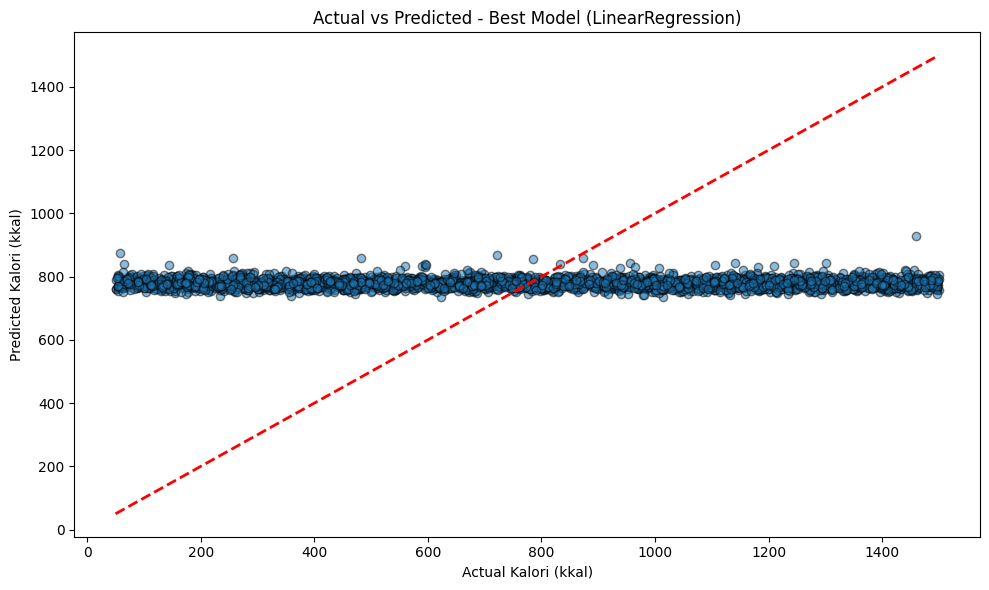

In [18]:
# Plot Actual vs Prediction
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred_best, alpha=0.5, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Kalori (kkal)')
plt.ylabel('Predicted Kalori (kkal)')
plt.title(f'Actual vs Predicted - Best Model ({type(best_model).__name__})')
plt.tight_layout()
plt.show()

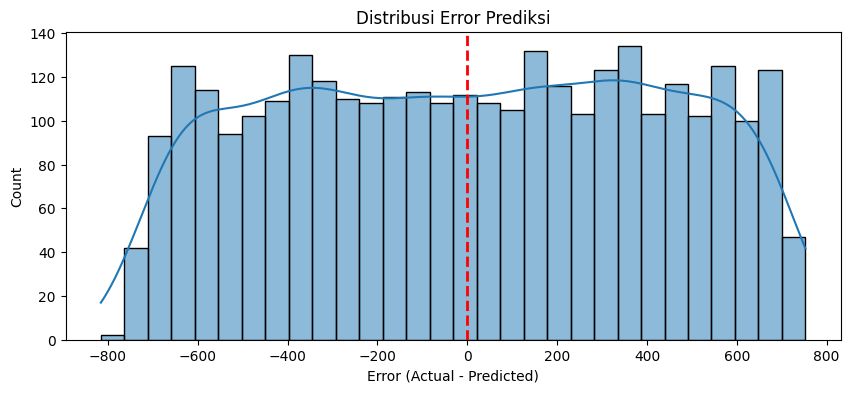

In [19]:
# Error distribution
errors = y_test - y_pred_best
plt.figure(figsize=(10,4))
sns.histplot(errors, bins=30, kde=True)
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.title('Distribusi Error Prediksi')
plt.xlabel('Error (Actual - Predicted)')
plt.show()

# 8. Feature Importance Analysis

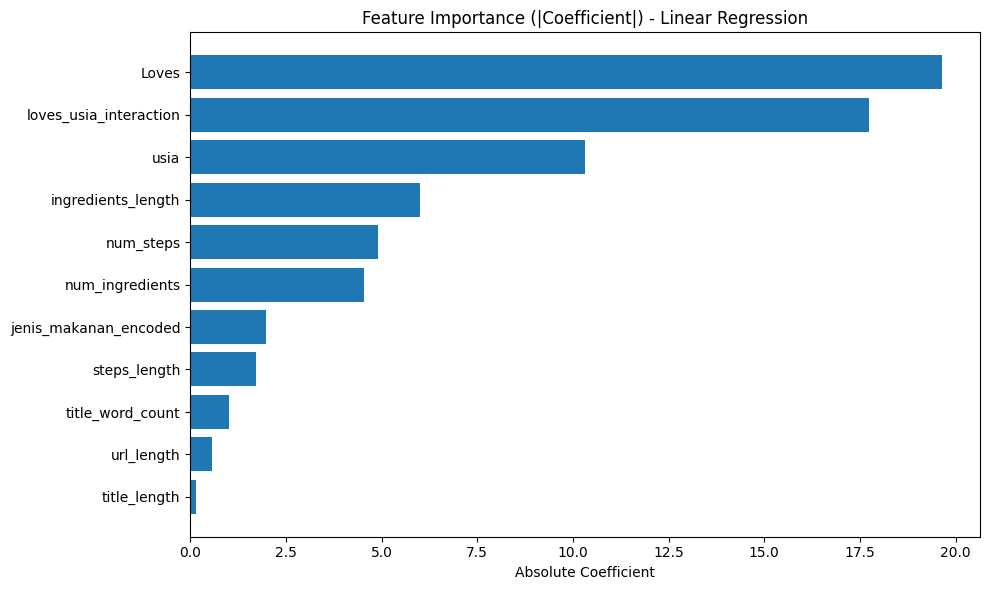

In [20]:
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1]
    plt.figure(figsize=(10,6))
    plt.barh(range(len(importances)), importances[indices], align='center')
    plt.yticks(range(len(importances)), [feature_columns[i] for i in indices])
    plt.gca().invert_yaxis()
    plt.xlabel('Feature Importance')
    plt.title(f'Feature Importance - {type(best_model).__name__}')
    plt.tight_layout()
    plt.show()

    print("\n=== Ranking Fitur Paling Berpengaruh ===")
    for i in range(min(10, len(importances))):
        print(f"{i+1}. {feature_columns[indices[i]]}: {importances[indices[i]]:.4f}")
else:
    # Linear Regression: gunakan koefisien absolut
    coef = best_model.coef_
    indices = np.argsort(np.abs(coef))[::-1]
    plt.figure(figsize=(10,6))
    plt.barh(range(len(coef)), np.abs(coef)[indices], align='center')
    plt.yticks(range(len(coef)), [feature_columns[i] for i in indices])
    plt.gca().invert_yaxis()
    plt.xlabel('Absolute Coefficient')
    plt.title('Feature Importance (|Coefficient|) - Linear Regression')
    plt.tight_layout()
    plt.show()

# 10. Model Saving

In [24]:
import joblib

joblib.dump(best_model, 'best_nutrision.pkl')
joblib.dump(scaler, 'scaler_food.pkl')
print("Model dan scaler disimpan.")

Model dan scaler disimpan.


In [26]:
# Contoh load dan prediksi
with open('best_calorie_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Contoh prediksi untuk satu sampel baru (misal dari baris pertama test set)
sample = X_test[0].reshape(1, -1)
pred = loaded_model.predict(sample)
print(f"Contoh prediksi untuk sampel test: {pred[0]:.2f} kkal")

Contoh prediksi untuk sampel test: 795.96 kkal


#Kesimpulan
Semua model gagal mencapai target (MAE ≈ 360 kkal >> 75; R² negatif/mendekati 0).

Model terbaik (Random Forest Tuned) memiliki MAE 361,69 dan R² -0,00.

Target bisnis tidak tercapai karena dataset tidak sesuai untuk prediksi kalori harian pengguna.